# Logistic regression: predictor exploration

Categorical predictors are one-hot encoded (one column per category, retaining all categories). Pearson correlations on these indicators measure relationships with category membership; arbitrary numeric category codes are not used. Correlations between levels of the same predictor partly reflect their mutual exclusivity. These are descriptive associations, not causal effects.

In [23]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    directory for directory in (Path.cwd(), *Path.cwd().parents)
    if (directory / "TEST_TRAIN" / "train.csv").is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from Models.logistic_regression import FEATURE_COLUMNS, CATEGORICAL_COLUMNS

train = pd.read_csv(PROJECT_ROOT / "TEST_TRAIN" / "train.csv")
predictors = train.loc[:, FEATURE_COLUMNS].copy()
numeric_columns = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_COLUMNS]
predictors[numeric_columns] = predictors[numeric_columns].apply(pd.to_numeric, errors="raise")
assert len(train) > 0, "The training dataset is empty."

## Predictor correlations

The heatmap includes every numeric predictor and every observed categorical level. Missing categorical values remain missing across their indicator columns. Pearson correlations use pairwise complete observations; undefined correlations (for example, constant columns) are blank. The pairwise sample-size table below records how many observations support each coefficient.

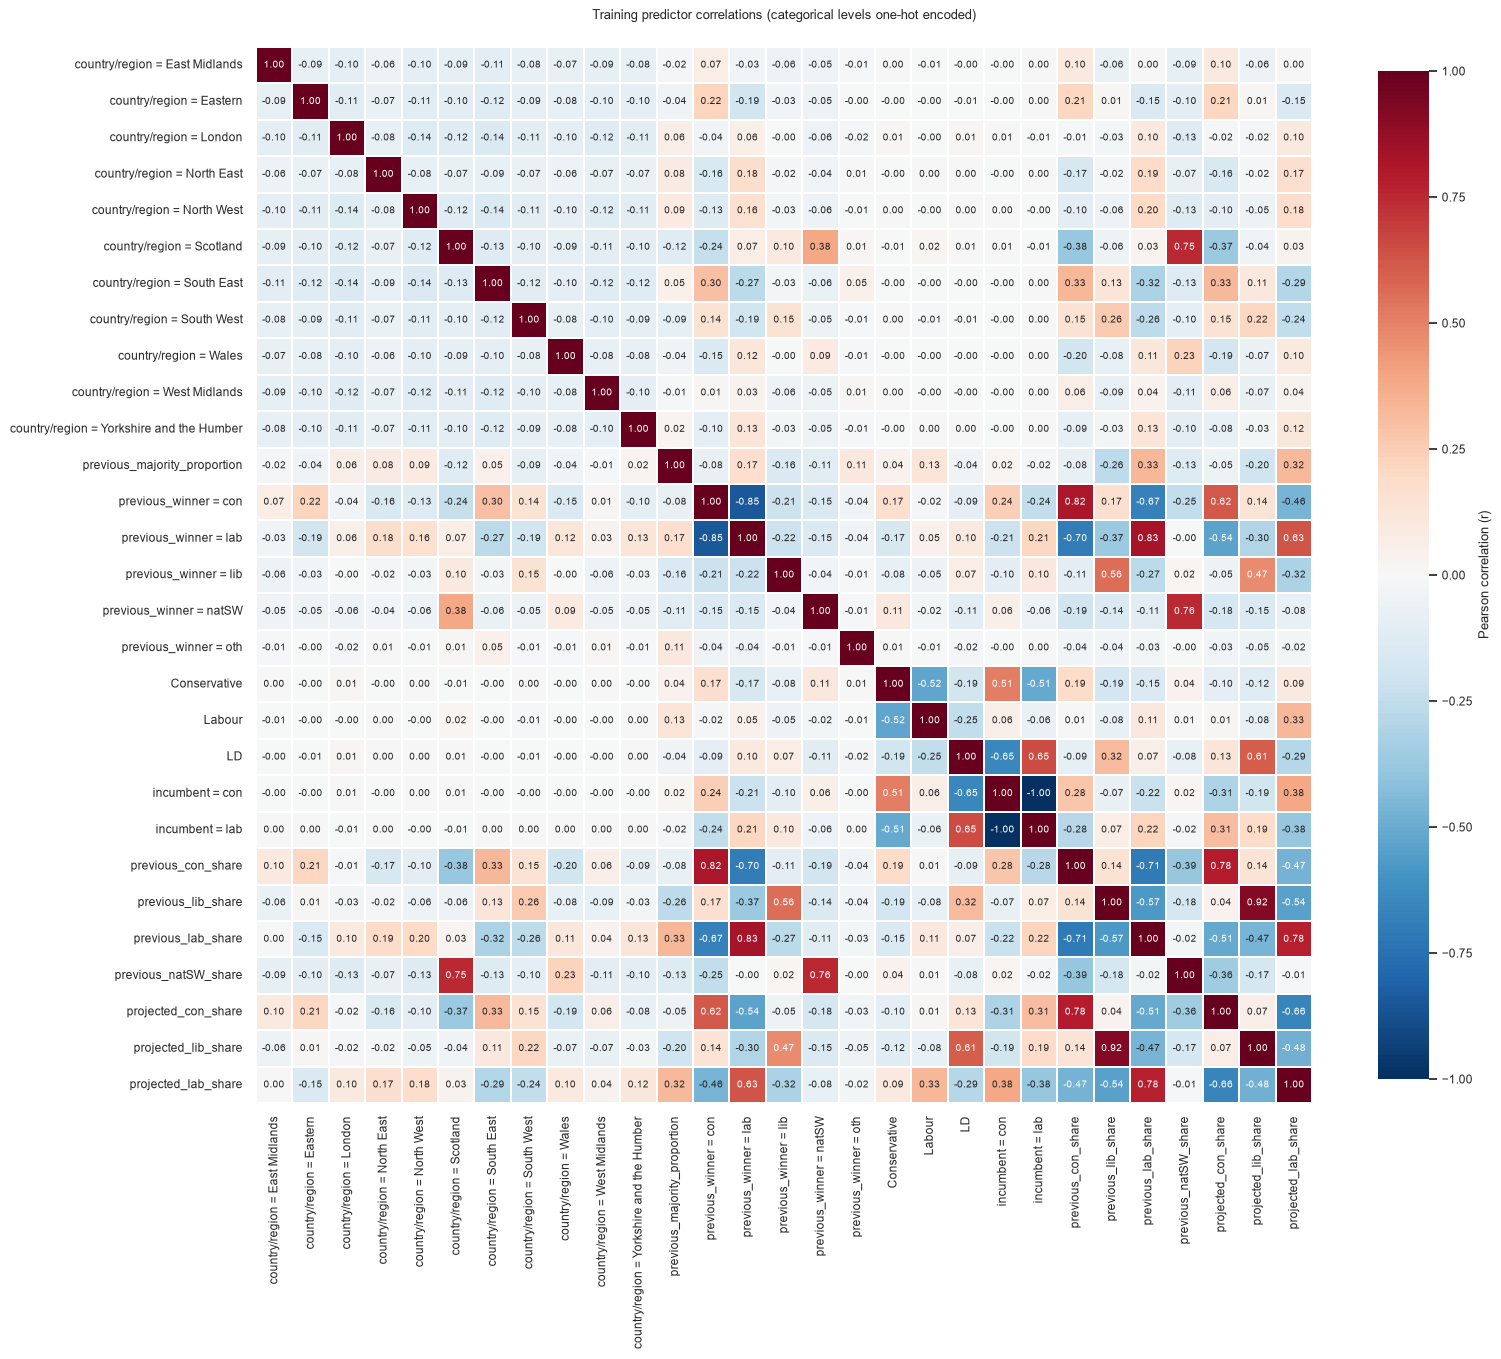

In [24]:
encoded_parts = []
for column in FEATURE_COLUMNS:
    if column in CATEGORICAL_COLUMNS:
        indicators = pd.get_dummies(predictors[column], prefix=column, prefix_sep=" = ", dtype=float)
        indicators.loc[predictors[column].isna(), :] = np.nan
        encoded_parts.append(indicators)
    else:
        encoded_parts.append(predictors[[column]])
encoded_predictors = pd.concat(encoded_parts, axis=1)
correlation_matrix = encoded_predictors.corr(method="pearson")
available = encoded_predictors.notna().astype("int64")
pairwise_counts = available.T @ available

sns.set_theme(style="white", font_scale=0.8)
size = max(14, len(correlation_matrix) * 0.55)
fig, ax = plt.subplots(figsize=(size, size))
sns.heatmap(
    correlation_matrix, mask=correlation_matrix.isna(),
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True, linewidths=0.3,
    cbar_kws={"label": "Pearson correlation (r)", "shrink": 0.7}, ax=ax,
)
ax.set_title("Training predictor correlations (categorical levels one-hot encoded)", pad=20)
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

## Categorical predictor counts and dataset percentages

Counts include only categorical predictors, using their original labels and a separate row for missing values. Each predictor has its own colour. Percentages use all training observations as the denominator, so each predictor's rows sum to 100% before rounding.


In [25]:
rows = []
for column in CATEGORICAL_COLUMNS:
    for category, count in predictors[column].value_counts(dropna=False).items():
        rows.append({
            "Predictor": column,
            "Category": "Missing" if pd.isna(category) else str(category),
            "Observations": count,
        })

category_summary = pd.DataFrame(rows)
category_summary["% of dataset"] = 100 * category_summary["Observations"] / len(train)

predictor_colours = dict(zip(
    CATEGORICAL_COLUMNS,
    sns.color_palette("husl", n_colors=len(CATEGORICAL_COLUMNS)).as_hex(),
))

def colour_predictor(row):
    colour = predictor_colours[row["Predictor"]]
    return [f"background-color: {colour}; color: #111111"] * len(row)

styled_summary = (
    category_summary.style.apply(colour_predictor, axis=1)
    .format({"Observations": "{:,.0f}", "% of dataset": "{:.2f}%"})
    .hide(axis="index")
    .set_caption(f"Categorical predictors - all {len(train):,} training observations")
)
display(styled_summary)


Predictor,Category,Observations,% of dataset
country/region,South East,740,12.97%
country/region,North West,686,12.02%
country/region,London,682,11.95%
country/region,Scotland,583,10.22%
country/region,West Midlands,529,9.27%
country/region,Eastern,502,8.80%
country/region,Yorkshire and the Humber,492,8.62%
country/region,South West,469,8.22%
country/region,East Midlands,400,7.01%
country/region,Wales,356,6.24%


The missingness in the 'previous_winner' predictor corresponds to newly created seats in 1997. We will need to deal with this and the 'oth' observations somehow, most likely from omitting them from the model. 

## Logistic regression diagnostics

Run the setup cell first. Use complete training rows and retain all winner labels, including `oth`, matching the current model. No test data are used and no rows are removed automatically.

### 1. Linearity with multinomial log-odds

Compare the linear model with a cubic spline for each continuous predictor in turn, adjusting for all other predictors. The assumption concerns log-probability ratios between winner classes, not raw probabilities. Splines allow these ratios to curve and accommodate zero/negative predictors without log transforms.

Leave-one-election-out validation keeps seats from the same election together. Positive **linear minus spline log loss** means the curved specification predicts the held-out election better. Consistent improvements suggest investigating nonlinearity. This is an exploratory check, not a formal hypothesis test or proof of linearity; regularization, correlated predictors and the small number of elections affect the comparison. It checks generalization across elections, not strictly forward-in-time forecasting.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import log_loss
from sklearn.exceptions import ConvergenceWarning
import warnings

diagnostic_data = train.dropna(subset=FEATURE_COLUMNS + ["winner"]).copy()
X_diag = diagnostic_data[FEATURE_COLUMNS].copy()
X_diag[numeric_columns] = X_diag[numeric_columns].apply(pd.to_numeric, errors="raise")
y_diag = diagnostic_data["winner"]
if not np.isfinite(X_diag[numeric_columns].to_numpy()).all():
    raise ValueError("Numeric predictors contain infinity; inspect these rows first.")
if y_diag.nunique() < 3:
    raise ValueError("These diagnostics expect the current multinomial outcome (3+ classes).")
if diagnostic_data["election"].isna().any() or diagnostic_data["election"].nunique() < 2:
    raise ValueError("Grouped validation requires known elections and at least two groups.")
continuous_predictors = [c for c in numeric_columns if X_diag[c].nunique() > 2]
print(f"Using {len(X_diag):,} complete rows; excluded {len(train) - len(X_diag):,} incomplete rows.")
print("Continuous predictors:", continuous_predictors)
print("Constant/binary numeric predictors (no curvature check):",
      [c for c in numeric_columns if c not in continuous_predictors])
display(y_diag.value_counts().rename("Observations").to_frame())

def diagnostic_pipeline(curved_predictor=None):
    transformers = [
        ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLUMNS),
        ("linear", StandardScaler(), [c for c in numeric_columns if c != curved_predictor]),
    ]
    if curved_predictor is not None:
        transformers.append(("curve", Pipeline([
            ("spline", SplineTransformer(n_knots=4, degree=3, knots="uniform",
                                         include_bias=False, extrapolation="linear")),
            ("scale", StandardScaler()),
        ]), [curved_predictor]))
    return Pipeline([
        ("preprocessing", ColumnTransformer(transformers)),
        ("classifier", LogisticRegression(C=1.0, solver="lbfgs", max_iter=5000, tol=1e-8)),
    ])

def fit_checked(estimator, X, y):
    # Stop rather than interpret diagnostics from an unconverged fit.
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        return estimator.fit(X, y)

classes_diag = np.sort(y_diag.unique())
fold_results = []
for fold, (fit_rows, validation_rows) in enumerate(
    LeaveOneGroupOut().split(X_diag, y_diag, diagnostic_data["election"]), start=1
):
    X_fit, X_validation = X_diag.iloc[fit_rows], X_diag.iloc[validation_rows]
    y_fit, y_validation = y_diag.iloc[fit_rows], y_diag.iloc[validation_rows]
    if set(y_fit) != set(classes_diag):
        raise ValueError("A training fold lacks an outcome class; revise the validation grouping.")
    linear_fit = fit_checked(diagnostic_pipeline(), X_fit, y_fit)
    linear_loss = log_loss(y_validation, linear_fit.predict_proba(X_validation), labels=classes_diag)
    election = diagnostic_data["election"].iloc[validation_rows[0]]
    for predictor in continuous_predictors:
        if X_fit[predictor].nunique() < 4:
            continue  # Too few distinct values for the chosen spline in this fold.
        spline_fit = fit_checked(diagnostic_pipeline(predictor), X_fit, y_fit)
        spline_loss = log_loss(y_validation, spline_fit.predict_proba(X_validation), labels=classes_diag)
        fold_results.append({"Predictor": predictor, "Held-out election": election,
                             "Linear log loss": linear_loss, "Spline log loss": spline_loss,
                             "Linear minus spline log loss": linear_loss - spline_loss})
    print(f"Completed election fold {fold}: {election}")

linearity_by_election = pd.DataFrame(fold_results)
if linearity_by_election.empty:
    print("No eligible continuous predictors/folds for the spline comparison.")
else:
    linearity_summary = linearity_by_election.groupby("Predictor").agg(
        elections=("Held-out election", "count"),
        mean_gain=("Linear minus spline log loss", "mean"),
        min_gain=("Linear minus spline log loss", "min"),
        max_gain=("Linear minus spline log loss", "max"),
        fraction_improved=("Linear minus spline log loss", lambda s: (s > 0).mean()),
    ).sort_values("mean_gain", ascending=False)
    display(linearity_summary.style.format(precision=4))
    display(linearity_by_election.pivot(index="Predictor", columns="Held-out election",
                                      values="Linear minus spline log loss").style.format(precision=4))
    ax = linearity_summary["mean_gain"].sort_values().plot.barh(figsize=(9, 6))
    ax.axvline(0, color="black", linewidth=1)
    ax.set(xlabel="Mean linear minus spline log loss (equal weight per election)",
           title="Positive values favour a curved predictor effect")
    plt.tight_layout()
    plt.show()

### 2. Influential observations

Fit the same L2-regularized multinomial specification with tighter convergence. Rank all observations by the local influence approximation **g_i transpose H pseudoinverse g_i**, where g_i is the observation's loss gradient and H is the penalized loss Hessian. Larger scores suggest greater effects on fitted parameters. The pseudoinverse handles the redundant common intercept. This is a screening score, not ordinary least-squares Cook's distance; binary GLM cutoffs are not applied.

Refit the entire pipeline after deleting each of the ten highest-scoring rows. Measure prediction changes on the *remaining* observations. A maximum class-probability change of 5 percentage points is an adjustable practical flag, not a significance threshold. Poorly predicted outcomes are also reported separately: a surprising result is not necessarily influential. Review flagged rows for errors and substantive explanations before considering exclusion.

Screening is approximate and deletion refits cover only the strongest candidates, so these checks cannot prove that no influential rows exist. Groups of observations or whole elections can also be influential together.

Model reference: [scikit-learn logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [ ]:
baseline_diagnostic = fit_checked(diagnostic_pipeline(), X_diag, y_diag)
classifier_diag = baseline_diagnostic.named_steps["classifier"]
transformed_diag = baseline_diagnostic.named_steps["preprocessing"].transform(X_diag)
if hasattr(transformed_diag, "toarray"):
    transformed_diag = transformed_diag.toarray()
design_diag = np.column_stack([np.ones(len(X_diag)), transformed_diag])
probabilities_diag = baseline_diagnostic.predict_proba(X_diag)
n_diag, p_diag = design_diag.shape
k_diag = probabilities_diag.shape[1]
class_indices_diag = pd.Index(classifier_diag.classes_).get_indexer(y_diag)
observed_diag = np.eye(k_diag)[class_indices_diag]

# Hessian of SUM negative log likelihood + ||coefficients||^2 / (2*C).
# Class-major parameter order; intercepts are not penalized.
hessian_diag = np.zeros((k_diag * p_diag, k_diag * p_diag))
for a in range(k_diag):
    for b in range(k_diag):
        weights = probabilities_diag[:, a] * ((1.0 if a == b else 0.0) - probabilities_diag[:, b])
        hessian_diag[a*p_diag:(a+1)*p_diag, b*p_diag:(b+1)*p_diag] = (
            design_diag.T @ (weights[:, None] * design_diag)
        )
penalty_diag = np.tile(np.r_[0.0, np.repeat(1.0 / classifier_diag.C, p_diag - 1)], k_diag)
hessian_diag += np.diag(penalty_diag)
inverse_hessian_diag = np.linalg.pinv(hessian_diag, rcond=1e-10, hermitian=True)
gradients_diag = ((probabilities_diag - observed_diag)[:, :, None]
                  * design_diag[:, None, :]).reshape(n_diag, -1)
influence_scores_diag = np.maximum(
    np.einsum("ij,ij->i", gradients_diag @ inverse_hessian_diag, gradients_diag), 0
)

identity_columns = [c for c in ["constituency_name", "constituency_id", "election", "winner"]
                    if c in diagnostic_data.columns]
influence_table = diagnostic_data[identity_columns].copy()
influence_table.insert(0, "train_row_index", diagnostic_data.index)
influence_table["Observed-class probability"] = probabilities_diag[np.arange(n_diag), class_indices_diag]
influence_table["Outcome surprise (-log p)"] = -np.log(
    np.clip(influence_table["Observed-class probability"], np.finfo(float).tiny, 1)
)
influence_table["Approximate influence"] = influence_scores_diag
print("Largest approximate influence scores:")
display(influence_table.sort_values("Approximate influence", ascending=False).head(20))
print("Least well-predicted observed outcomes (not automatically influential):")
display(influence_table.sort_values("Outcome surprise (-log p)", ascending=False).head(10))

TOP_N_DELETIONS = 10
PROBABILITY_CHANGE_FLAG = 0.05  # 5 percentage points; choose for the application.
candidates_diag = np.argsort(-influence_scores_diag)[:min(TOP_N_DELETIONS, n_diag)]
deletion_results = []
for position in candidates_diag:
    keep = np.arange(n_diag) != position
    record = influence_table.iloc[position].to_dict()
    if set(y_diag.iloc[keep]) != set(classifier_diag.classes_):
        record["Status"] = "Review: deleting this row removes an entire outcome class"
        record["Flag for review"] = True
    else:
        deleted_fit = fit_checked(clone(baseline_diagnostic), X_diag.iloc[keep], y_diag.iloc[keep])
        deleted_probabilities = deleted_fit.predict_proba(X_diag.iloc[keep])
        changes = np.abs(deleted_probabilities - probabilities_diag[keep]).max(axis=1)
        record.update({
            "Mean max probability change": changes.mean(),
            "Largest probability change": changes.max(),
            "Fraction of predicted winners changed": np.mean(
                deleted_probabilities.argmax(axis=1) != probabilities_diag[keep].argmax(axis=1)),
            "Flag for review": bool(changes.max() >= PROBABILITY_CHANGE_FLAG),
            "Status": "Refit complete",
        })
    deletion_results.append(record)

deletion_summary = pd.DataFrame(deletion_results)
display(deletion_summary)
flag_count = int(deletion_summary["Flag for review"].sum())
print(f"{flag_count} of {len(deletion_summary)} screened deletion candidates flagged for review "
      f"(probability-change threshold: {PROBABILITY_CHANGE_FLAG:.0%}, or loss of a class).")
if flag_count == 0:
    print("No material influence detected among these candidates at this threshold; "
          "this does not rule out other influential rows or groups.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(influence_table["Outcome surprise (-log p)"], influence_scores_diag, alpha=0.45, s=14)
for position in candidates_diag:
    ax.annotate(str(diagnostic_data.index[position]),
                (influence_table["Outcome surprise (-log p)"].iloc[position], influence_scores_diag[position]),
                fontsize=8)
ax.set(xlabel="Outcome surprise (-log predicted probability of observed winner)",
       ylabel="Approximate influence score", title="Influence screening (labels are training row indexes)")
plt.tight_layout()
plt.show()

Seems reasonable to drop the 'oth' rows in the data set for logistic regression as many of the observations are highly influential.